# Rough Bergomi / Lookback Fixed Calls Price + Gradient Production Audit 01

Validate the first 100 production rows with the four independent engines.

## Load Data And Timings

Load the production audit and display the common four-engine timing view.

,wall seconds,kernel seconds
engine,,
cpp cuda,0.2995,0.2995
pytorch gpu,0.3234,-
cpp cpu,4.383,-
pytorch cpu,11.73,-


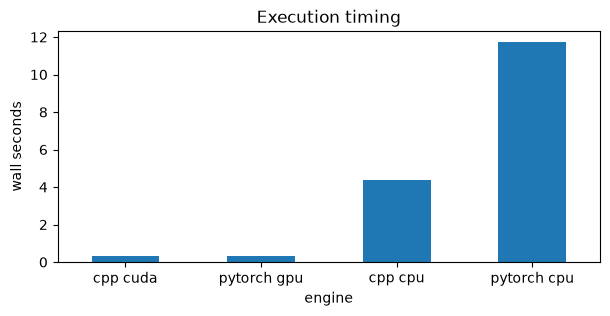

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "registry").is_dir())
PROJECT_ROOT = ROOT
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src_python") not in sys.path:
    sys.path.insert(0, str(ROOT / "src_python"))

from tools.validation.audit import load_production_audit, timing_frame

pd.set_option("display.precision", 4)
audit = load_production_audit(
    ROOT,
    model_family='rough_bergomi',
    product_family='lookback_fixed_calls',
    delta_crn=True,
)
cpp_gpu = audit.validation["cpp_gpu"].data
python_gpu = audit.validation["python_gpu"].data
cpp_cpu = audit.validation["cpp_cpu"].data
python_cpu = audit.validation["python_cpu"].data
cpp_gpu_spec = audit.validation["cpp_gpu"].specification
cpp_gpu_spec_summary = cpp_gpu_spec["summary"]
production = audit.production.data
production_head = production["results"][:100]
data = {key: document.data for key, document in audit.validation.items()}
specs = {key: document.specification for key, document in audit.validation.items()}
paths = {key: document.json_path for key, document in audit.validation.items()}
spec_paths = {key: document.yaml_path for key, document in audit.validation.items()}
spec_path = spec_paths["cpp_gpu"]
result_path = paths["cpp_gpu"]
PRODUCT_FAMILY = 'lookback_fixed_calls'
performance = timing_frame(audit)
benchmark_row_count = performance.attrs.get("benchmark_row_count")
if benchmark_row_count and benchmark_row_count != 100:
    print(
        f"Performance timing uses one hot call over {benchmark_row_count:,} "
        "benchmark rows; correctness retains the 100-row audit slice."
    )
display(performance.style.format("{:.4g}", na_rep="-"))
ax = performance["wall seconds"].plot(kind="bar", figsize=(7, 3), rot=0)
ax.set_ylabel("wall seconds")
ax.set_title("Execution timing")
plt.show()

## Dataset Coherence

Apply the production, native reproducibility, and statistical checks.

In [2]:
from tools.validation.audit import coherence_frame

coherence = coherence_frame(audit)
display(
    coherence.style.format(
        {
            "max abs error": "{:.3e}",
            "max rel error (%)": "{:.3f}",
            "max z-score": "{:.3f}",
        },
        na_rep="-",
    )
)

,output,max abs error,max rel error (%),relative rows,max z-score
check,,,,,
production stored cpp cuda vs regenerated cpp cuda,price,1.110e-16,0.000,100,0.000
cpp cpu vs cpp cuda,price,1.804e-14,0.000,100,0.000
pytorch cpu vs pytorch gpu,price,9.880e-03,36.748,100,3.258
cpp cuda vs pytorch gpu,price,6.536e-03,46.547,100,2.217
production stored cpp cuda vs regenerated cpp cuda,delta,2.220e-16,0.000,100,0.000
cpp cpu vs cpp cuda,delta,2.220e-14,0.000,100,0.000
pytorch cpu vs pytorch gpu,delta,1.574e-02,14.242,100,3.258
cpp cuda vs pytorch gpu,delta,1.390e-02,19.600,100,2.542
cpp cuda price-only vs price-and-gradient,price,0.000e+00,0.000,100,0.000


## Path Reconstruction Check

Reconstruct the exact Philox paths for one production row and reprice it.

In [3]:
from tools.paths.rough_bergomi import price_lookback_from_paths, reconstruct_paths_for_result

row_id = "000001"
result_json_path = "registry/production/results/rough_bergomi/lookback_fixed_calls/data/rough_bergomi_01__lookback_fixed_calls_01__cpp_gpu_philox_delta_crn_01.json"
result_yaml_path = "registry/production/results/rough_bergomi/lookback_fixed_calls/specifications/rough_bergomi_01__lookback_fixed_calls_01__cpp_gpu_philox_delta_crn_01.yaml"
paths, kernel_seconds, stored_row, model, product, spec = reconstruct_paths_for_result(
    result_json_path=result_json_path,
    result_yaml_path=result_yaml_path,
    row_id=row_id,
    use_gpu=True,
)
strike = float(product["strike"])
maturity = float(product["maturity"])
rate = float(model["risk_free_rate"])
spot = float(model["spot"])
relative_bump = float(spec["delta_method"]["relative_bump"])
base = price_lookback_from_paths(paths, strike=strike, maturity=maturity, rate=rate)
up = price_lookback_from_paths(
    [[value * (1.0 + relative_bump) for value in path] for path in paths],
    strike=strike,
    maturity=maturity,
    rate=rate,
)
down = price_lookback_from_paths(
    [[value * (1.0 - relative_bump) for value in path] for path in paths],
    strike=strike,
    maturity=maturity,
    rate=rate,
)
repriced_delta = (up["price"] - down["price"]) / (2.0 * spot * relative_bump)
stored_price = float(stored_row["outputs"]["price"])
stored_delta = float(stored_row["outputs"]["delta"])
path_check = pd.DataFrame(
    [
        {
            "row id": row_id,
            "stored price": stored_price,
            "path repriced price": base["price"],
            "price abs error": abs(stored_price - base["price"]),
            "stored delta": stored_delta,
            "path repriced delta": repriced_delta,
            "delta abs error": abs(stored_delta - repriced_delta),
            "path export seconds": kernel_seconds,
        }
    ]
).set_index("row id")
display(
    path_check.style.format(
        {
            "stored price": "{:.6f}",
            "path repriced price": "{:.6f}",
            "abs error": "{:.2e}",
            "price abs error": "{:.2e}",
            "stored delta": "{:.6f}",
            "path repriced delta": "{:.6f}",
            "delta abs error": "{:.2e}",
            "path export seconds": "{:.3f}",
        },
        na_rep="-",
    )
)

,stored price,path repriced price,price abs error,stored delta,path repriced delta,delta abs error,path export seconds
row id,,,,,,,
000001,0.053662,0.053662,1.39e-17,0.334515,0.334515,1.65e-13,0.012


## Regeneration Commands

Native build:

```bash
cmake -S src_cpp -B /tmp/ai_factory_cpp_build -DCMAKE_BUILD_TYPE=Release
cmake --build /tmp/ai_factory_cpp_build --target ai_factory_cuda_shared -j
```

Production parameter databases:

```bash
python registry/production/models/rough_bergomi/generators/rough_bergomi_01.py
python registry/production/products/lookback_fixed_calls/generators/lookback_fixed_calls_01.py
```

Production priced database with CRN delta:

```bash
python registry/production/results/rough_bergomi/lookback_fixed_calls/generators/rough_bergomi_01__lookback_fixed_calls_01__cpp_gpu_philox_delta_crn_01.py
```

Validation audit slices:

```bash
python registry/validation/models/rough_bergomi/generators/rough_bergomi_01__first_100.py
python registry/validation/products/lookback_fixed_calls/generators/lookback_fixed_calls_01__first_100.py
```

Validation repricing:

```bash
python registry/validation/results/rough_bergomi/lookback_fixed_calls/generators/rough_bergomi_01__first_100__lookback_fixed_calls_01__first_100__cpp_gpu_philox_delta_crn_01.py
python registry/validation/results/rough_bergomi/lookback_fixed_calls/generators/rough_bergomi_01__first_100__lookback_fixed_calls_01__first_100__cpp_cpu_philox_delta_crn_01.py
python registry/validation/results/rough_bergomi/lookback_fixed_calls/generators/rough_bergomi_01__first_100__lookback_fixed_calls_01__first_100__python_gpu_pytorch_delta_crn_01.py
python registry/validation/results/rough_bergomi/lookback_fixed_calls/generators/rough_bergomi_01__first_100__lookback_fixed_calls_01__first_100__python_cpu_pytorch_delta_crn_01.py
```